# Foundations of Machine learning

Problem Set 2

Emily Fu

In [1]:
# importing packages and methods

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# setting parameters

# possible dimensions of theta
dim_thetas = [2, 3, 10]

# number of draws
nreps = 10000

# vary the values of r
# wasn't really sure how to do this
r_grid = np.linspace(0, 6, 61)

# function to calculate loss 1/k ||theta - thetahat||^2 in each draw
def loss_per_draw(theta, thetahat):

    # pivot to calculate loss per draw
    theta = np.asarray(theta).reshape(1, -1)

    # dimension of theta
    k = theta.shape[1]

    # return loss per draw
    return(np.sum((thetahat - theta) ** 2, axis=1) / k)


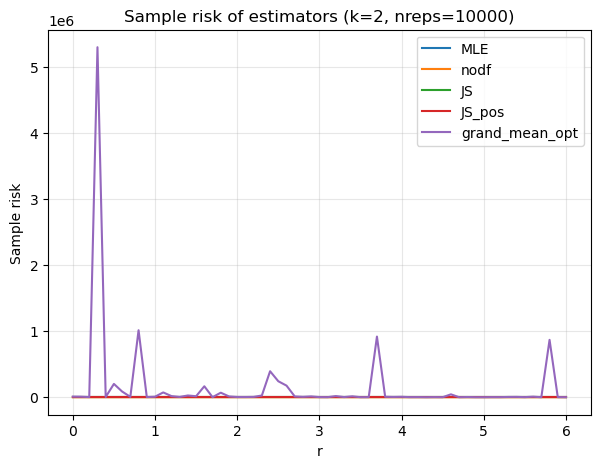

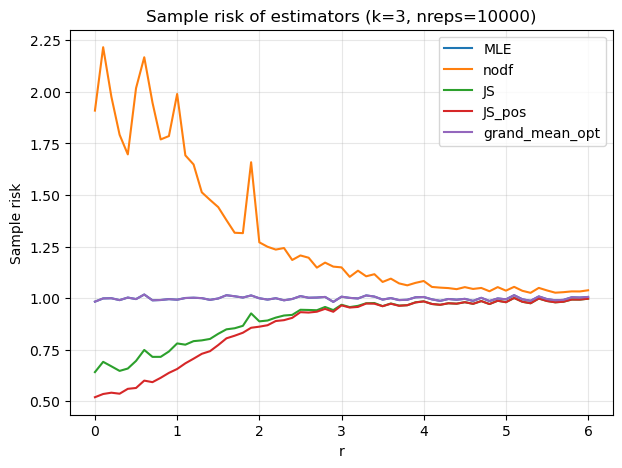

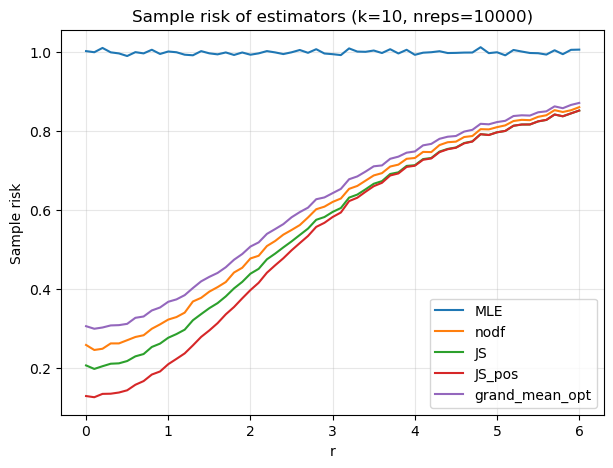

In [ ]:
# container to store risk curves
risks = {}

for k in dim_thetas:
    # print(k)

    # 1. Pick a random vector theta_1 of length 1 
    # (you can pick random normally distributed components and then normalize),
    theta_1 = np.random.normal(size=k)
    theta_1 = theta_1 / np.linalg.norm(theta_1)
    
    # initialise risk curves for each estimator at this dimension
    risks[k] = {'MLE': np.zeros(len(r_grid)),
                'nodf': np.zeros(len(r_grid)),
                'JS': np.zeros(len(r_grid)),
                'JS_pos': np.zeros(len(r_grid)),
                'grand_mean_opt': np.zeros(len(r_grid))}

    for i, r in enumerate(r_grid):

        # 2. take θ = r*theta_1 for r in [0, 6],
        theta = r * theta_1

        # print(f'Dimension: {k}, r: {r}')

        # 3. repeatedly (say, 10,000 times) draw X ∼ N(theta, I),
        X = np.random.multivariate_normal(mean=theta, cov=np.eye(k), size=nreps)

        # mean of Xs, squared Xs, and variance

        # sum of squared X
        X_norm2 = np.sum(X**2, axis=1, keepdims=True)

        # mean of squared X
        X2_bar = X_norm2 / k

        # mean of X
        Xbar = np.mean(X, axis=1, keepdims=True)

        # variance of X
        s2_X = np.mean((X - Xbar) ** 2, axis=1, keepdims=True)

        # print(X2_bar)
        # print(Xbar)
        # print(s2_X)

        # calculate estimates theta_hat

        # 1. the MLE
        thetahat_MLE = X

        # 2. the estimator (1 - 1/X2_bar)*X
        # i think this is the no degrees of freedom thing
        shrink_nodf = 1 - (1 / (X2_bar))
        thetahat_nodf = shrink_nodf * X

        # 3. the James-Stein estimator
        shrink_js = 1 - ((k - 2) / k) / (X2_bar)
        thetahat_js = shrink_js * X

        # 4. the positive part James-Stein estimator,
        # take zero whenever shrinkage factor is negative
        shrink_js_pos = np.maximum(0, shrink_js)
        thetahat_js_pos = shrink_js_pos * X

        # 5. the estimator shrinking to the grand mean using the 
        # optimal shrinkage factor 1 - ((k - 3) / k) / s2_X
        shrink_grand = 1 - (((k - 3) / k) / (s2_X))
        # the estimator is of the form thetahat_i = a + bX_i so thetabar = a + bXbar
        # and E[Xbar] = thetabar, so i'd use the feasible version a = (1 - b)Xbar and b = shrink_grand
        # simplified, this gives us the estimator below
        thetahat_optimal = Xbar + shrink_grand * (X - Xbar)

        # evaluating average loss across all simulation draws for each estimator
        risks[k]['MLE'][i] = np.mean(loss_per_draw(theta, thetahat_MLE))
        risks[k]['nodf'][i] = np.mean(loss_per_draw(theta, thetahat_nodf))
        risks[k]['JS'][i] = np.mean(loss_per_draw(theta, thetahat_js))
        risks[k]['JS_pos'][i] = np.mean(loss_per_draw(theta, thetahat_js_pos))
        risks[k]['grand_mean_opt'][i] = np.mean(loss_per_draw(theta, thetahat_optimal))

    # For a given dimension, plot the risk functions of all these estimators in one figure.
    plt.figure(figsize=(7, 5))
    for name, curve in risks[k].items():
        plt.plot(r_grid, curve, label=name)
    plt.title(f'Sample risk of estimators (k={k}, nreps={nreps})')
    plt.xlabel('r')
    plt.ylabel('Sample risk')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


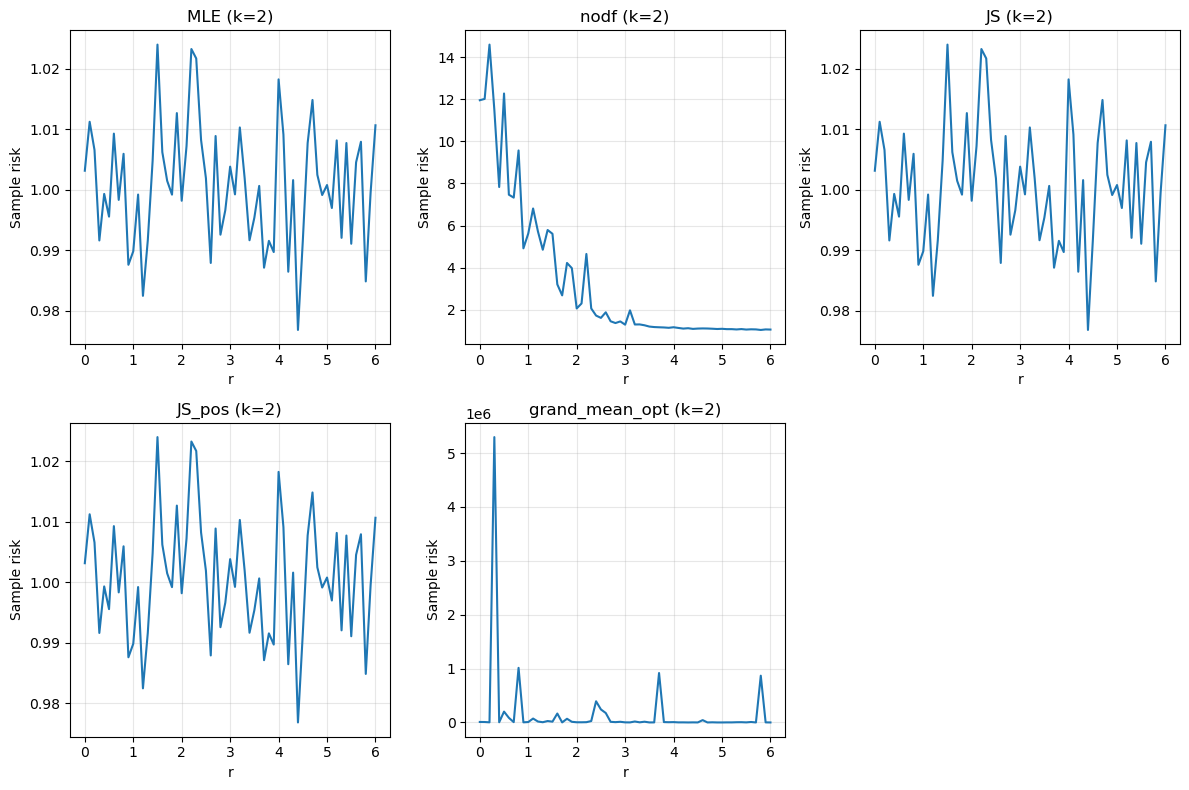

In [13]:
# plot k=2 with separate plot for each estimator to see the differences more clearly
plt.figure(figsize=(12, 8))
k = 2
for i, (name, curve) in enumerate(risks[k].items()):
    plt.subplot(2, 3, i + 1)
    plt.plot(r_grid, curve, label=name)
    plt.title(f'{name} (k={k})')
    plt.xlabel('r')
    plt.ylabel('Sample risk')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

At $k = 2$:

- There are very large spikes in empirical risk for the estimator shrinking to the grand mean. I think this is because the standard deviation that I evaluate for each simulation draw is only caculated using two points, so it's more likely to have a very small variance by getting two similar $X$ values, which then estimates a very large $\bf{\hat{\theta}}$.
- The MLE estimated risk stays around one. I think this comes from us drawing the $X$ s from the normal distribution around $\theta$. The James-Stein estimator and the MLE are the same based on the formula (the shrinkage factor just goes to 1 since the second term is zero). Hence, the positive part James-Stein estimator is also the same as MLE.
- Meanwhile, the James-Stein estimator with no degrees of freedom correction, $(1 - 1/\bar{\bf{X}^2})*\bf{X}$, is decreasing in sample risk in $r$ but is dominated by regular James-Stein/MLE/positive-part James-Stein.

At $k = 3$:
- It looks like the MLE estimates and the estimates shrinking to the grand mean all have the same empirical risk of around one. Since $k = 3$, the optimal shrinkage factor becomes 1. That means the estimator shrinking to the grand mean is the same as the MLE. The empirical risk usng these estimators is higher than that of the positive part James-Stein estimator and the James-Stein estimator because of the uniform risk dominance result
- The positive part James-Stein estimator dominates the James-Stein estimator as we saw in lecture
- Meanwhile, the James-Stein estimator with no degrees of freedom correction, $(1 - 1/\bar{\bf{X}^2})*\bf{X}$, is decreasing in sample risk in $r$.

At $k = 10$:
- The MLE empirical risk still stays around one and the estimator $(1 - 1/\bar{\bf{X}^2})*\bf{X}$ has slightly lower empirical risk for all values of $r$, but is increasing towards the MLE empirical risk as $r$ increases. The empirical risk for these estimators is higher than that of the positive part James-Stein estimator and the James-Stein estimator.
-  The positive part James-Stein estimator dominates the James-Stein estimator, which itself dominates the estimator shrinking to the grand mean. The James-Stein estimator, positive part James-Stein estimator, and estimator shrinking to the grand mean are converging to each other as $r$ increases. 
- The degrees of freedom correction makes the James-Stein estimator have lower empirical risk because it does correct for how many $\theta_i$ there are
- The estimator shrinking to the grand mean is dominated by James-Stein and positive part James-Stein. I'm guessing it could be because the actual DGP is `theta = r * theta_1` which isn't the same as generating it with an intercept

In the normal means setting, $\bf{X}$ can be written as $\bf{X} = \bf{\theta} + \bf{\epsilon} ∼ N(\bf{\theta}, \bf{I}_k)$. Then, $\theta = r*\bf{\theta}_{1}$ so that we get $\bf{X} = r * \bf{\theta}_{1} + \bf{\epsilon}$. In the James-Stein estimators, the $\bar{\bf{X}^2}$ term makes the shrinkage term be closer to 1 the larger the value of $r$ is, since then the $X$ s are also larger. This puts it closer to the MLE estimates. The loss in this assignment is divided by $k$ while the loss from the normal means model slides is not, but we can still see that risk improvement over MLE shrinks as $r$ increases, which is why the risk is higher at larger values of $r$. In the estimator shrinking to the grand mean, the variance also increases with r through $\frac{1}{k}\sum_i (\theta_i - \bar\theta)^2 = r^2 \cdot \frac{1}{k}\sum_i (\theta_{1,i} - \bar\theta_1)^2$, with how the $X$ s are generated, which similarly makes this estimator approach MLE.

